In [31]:
import base64
from glob import glob
import io
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
from random import seed
import seaborn as sns
import shutil
import tempfile
import random

In [5]:
path_to_drive = '/Volumes/Seagate Portable Drive'
db_path = '/Volumes/Seagate Portable Drive/KYLE_AI_DATABASE/Detections_inventory/Detections inventory_2023.08.29.xlsx'
db = pd.read_excel(db_path, sheet_name=1)
db['Folder path'] = db['Folder path'].str.replace('D:', path_to_drive).str.replace('\\', '/')
db['Marks'] = db['Marks'].str.replace(' marks', '')
db = db.rename(columns=str.lower)
db['ymdh'] = db['year'].astype(str) + db['date-time'].str.replace('.', '').str.replace('-','')
db.drop(columns=['date-time', 'link'], inplace=True)
db = db.rename(columns={'type': 'color', 'folder path': 'folder_path'})
db['color'] = db['color'].apply(lambda x: 1 if x == 'COLOR' else 0)
db = db[db['marks'] != 'Unsorted']
db['label'] = db['marks'].map({'No': 0, 'Partial': 0, 'Robust': 1})
db['label'] = db['label'].astype(int)

In [7]:
def sample_group(group, n=10,seed=1984):
    # If the group has 10 or more rows, sample ten rows
    if len(group) > n:
        return group.sample(n=n, random_state=seed)
    # If the group has fewer than ten rows, return the entire group
    # You can adjust this behavior as needed
    else:
        return group

sampled_db = db.groupby(['marks','id','year','color']).apply(sample_group).reset_index(drop=True)
print(f'Sampled {len(sampled_db)} rows from db')

Sampled 705 rows from db


/var/folders/vp/1c12nhtx09ng562vszvlczthvwd07y/T/ipykernel_56865/3393379207.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_db = db.groupby(['marks','id','year','color']).apply(sample_group).reset_index(drop=True)


In [8]:
sampled_db.head()

,folder_path,group,species,id,station,year,color,marks,ymdh,label
0,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,No,201603122132,0
1,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,HC,2020,0,No,202004090034,0
2,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,JC,2020,0,No,202004122114,0
3,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,JC,2020,0,No,202004122120,0
4,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,JC,2020,0,No,202004122134,0


In [9]:
import json

robust_samples = sampled_db[sampled_db['label'] == 1]

folder_paths_dict = robust_samples['folder_path'].to_dict()

target_dirs_json = 'robust_target_dirs.json'
robust_validated_dirs = 'data/robust_validated_checkbox'

with open(target_dirs_json, 'w') as file:
    json.dump(folder_paths_dict, file)

In [122]:
!python image_selector_checkbox.py $target_dirs_json

INFO:     Started server process [38481]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     127.0.0.1:50334 - "GET / HTTP/1.1" 200 OK
INFO:     ('127.0.0.1', 50335) - "WebSocket /websocket/" [accepted]
INFO:     connection open
Logged 3 images from /Volumes/Seagate Portable Drive/KYLE_AI_DATABASE/A_CAMERA/Focal_species/Gulo gulo/BDF10-M6/SC/2020/B&W/Robust marks/04.11-04.45
Logged 2 images from /Volumes/Seagate Portable Drive/KYLE_AI_DATABASE/A_CAMERA/Focal_species/Gulo gulo/BDF10-M6/SC/2020/B&W/Robust marks/05.03-21.17
Logged 1 images from /Volumes/Seagate Portable Drive/KYLE_AI_DATABASE/A_CAMERA/Focal_species/Gulo gulo/BDF10-M6/SC/2020/B&W/Robust marks/05.03-21.36
Logged 1 images from /Volumes/Seagate Portable Drive/KYLE_AI_DATABASE/A_CAMERA/Focal_species/Gulo gulo/BDF10-M6/SC/2020/B&W/Robust marks/05.03-21.51
Logged 2 images from /Volumes/Seagate Portable Drive/KYLE_AI

### Resume here upon return from spring break ####

In [18]:
robust_valid_files = pd.read_csv('verified_robust_images.csv')
clean_robust = robust_valid_files.merge(sampled_db, right_on='folder_path', left_on='src_dir', how='left')
clean_robust.drop('src_dir', axis=1, inplace=True)

clean_robust

,basename,folder_path,group,species,id,station,year,color,marks,ymdh,label
0,IMG_2478.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,Robust,201604062211,1
1,IMG_2477.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,Robust,201604062211,1
2,IMG_2481.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,Robust,201604062211,1
3,IMG_1380.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,HC,2016,0,Robust,201603081818,1
4,IMG_1382.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,BDF10-M6,HC,2016,0,Robust,201603081818,1
...,...,...,...,...,...,...,...,...,...,...,...
526,RCNX0283.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,Turk,DM,2023,1,Robust,202303141056,1
527,RCNX0287.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,Turk,DM,2023,1,Robust,202303141056,1
528,RCNX0095.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,Turk,DM,2023,1,Robust,202304100216,1
529,RCNX0096.JPG,/Volumes/Seagate Portable Drive/KYLE_AI_DATABA...,Focal_species,Gulo gulo,Turk,DM,2023,1,Robust,202304100216,1


In [172]:
random.seed(1984)

# Assuming sampled_db is a pre-existing DataFrame
sampled_poor_db = sampled_db[sampled_db['marks'] != 'Robust']

# Collect all rows to be added to the new DataFrame in a list
data = []
samps_per_folder = 5

# Iterate over the rows of sampled_poor_db
for index, row in sampled_poor_db.iterrows():
    # Sample 3 files from the folder_path
    candidates = glob(os.path.join(row['folder_path'], '*'))
    candidates = [f for f in candidates if f.lower().endswith('.jpg')  or f.lower().endswith('.jpeg')]
    files = random.sample(candidates, min(samps_per_folder, len(candidates)))
    
    # For each file sampled, create a record
    for file in files:
        basename = os.path.basename(file)
        data.append({**row.to_dict(), 'basename': basename})

# Create the DataFrame from the collected data
sampled_poor_files = pd.DataFrame(data)

# Specify the column order, if necessary
column_order = ['basename', 'folder_path', 'group', 'species', 'id', 'station', 'year', 'color', 'marks', 'ymdh', 'label']
sampled_poor_files = sampled_poor_files[column_order]

# Display the sampled files
len(sampled_poor_files)

2142

In [173]:
full_set = pd.concat([clean_robust, sampled_poor_files], axis=0)
len(full_set)

2673

In [174]:
full_set['file_size'] = 0

# Iterate over the DataFrame and update the file size for each row
for index, row in full_set.iterrows():
    file_path = os.path.join(row['folder_path'], row['basename'])
    file_size = os.path.getsize(file_path)
    full_set.at[index, 'file_size'] = file_size

In [176]:
def split_data_by_min_ymdh(group):
    sorted_group = group.sort_values(by='ymdh', ascending=False)
    total_ones = sorted_group['label'].sum()
    target_ones = total_ones * 0.15 if total_ones >= 5 else 1

    count_ones = 0
    min_ymdh = sorted_group.iloc[1]['ymdh']  # Start with the last (earliest) date

    for _, row in sorted_group.iterrows():
        if row['label'] == 1:
            count_ones += 1
        if count_ones >= target_ones:
            min_ymdh = row['ymdh']
            break

    # Filter rows for train and test sets based on the identified minimum 'ymdh'
    train_data = group[group['ymdh'] < min_ymdh]
    test_data = group[group['ymdh'] >= min_ymdh]

    return train_data, test_data

# Initialize empty DataFrames for the train and test sets
train_set = pd.DataFrame()
test_set = pd.DataFrame()

# Apply the new splitting function to each group
for id_group, group in full_set.groupby('id'):
    train_data, test_data = split_data_by_min_ymdh(group)
    train_set = pd.concat([train_set, train_data])
    test_set = pd.concat([test_set, test_data])


# Calculate the counts of unique label values for each id in both train and test sets again
train_counts = train_set.groupby('id')['label'].value_counts().unstack(fill_value=0)
test_counts = test_set.groupby('id')['label'].value_counts().unstack(fill_value=0)

# Combine counts into a single dataframe for display
combined_counts = pd.concat([train_counts, test_counts], axis=1, keys=['Train', 'Test'])
combined_counts

Train      Test    
label           0    1    0   1
id                             
BDF10-M6      274  111  106  20
HFW12-F7      120   24   15   5
HLC20-H3      587  112  145  23
HLC21-H1       10    1    0   2
LH23-M1       120   26   80   5
PA23-F1       165   34   35   6
PA23-M1        15    5    5   1
PA23-M2        20    8    5   3
Powder Paws     5   12   15   4
Tex            30   41    5   8
Turk          290   66   95  14

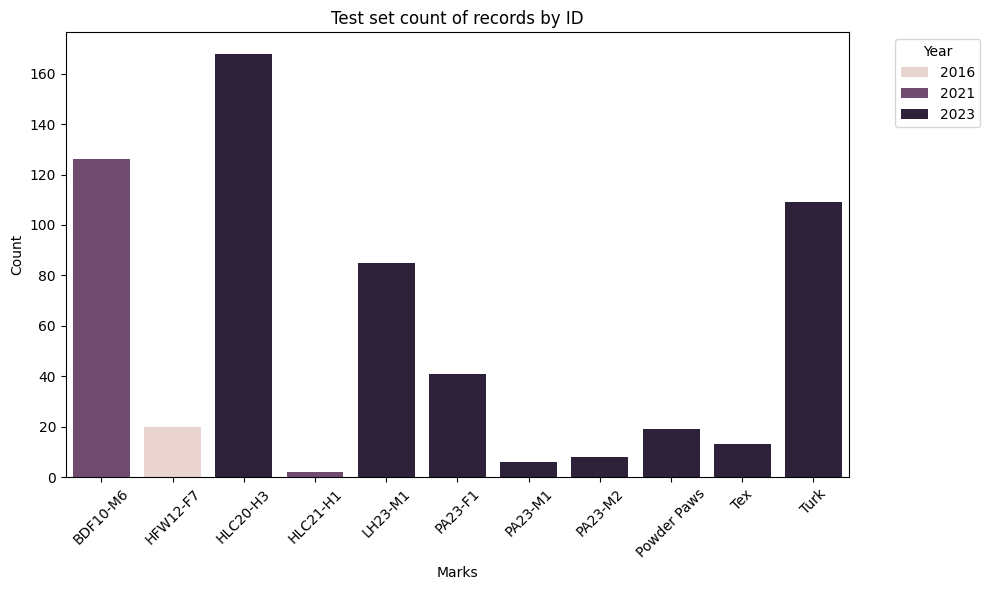

In [177]:
plt.figure(figsize=(10, 6))
sns.countplot(x='id', hue='year', data=test_set)
plt.title('Test set count of records by ID')
plt.xlabel('Marks')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place the legend outside the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

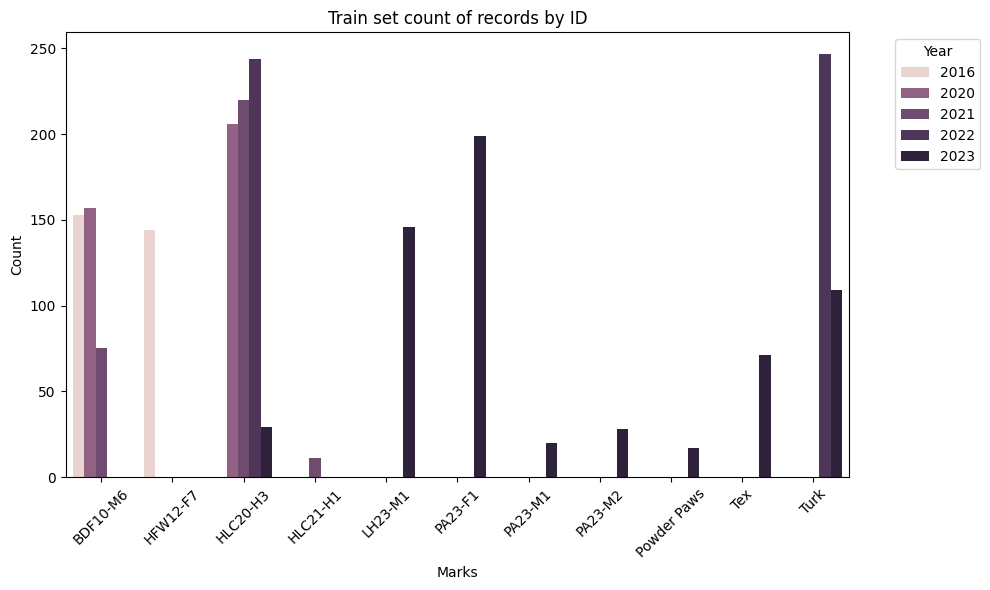

In [178]:
plt.figure(figsize=(10, 6))
sns.countplot(x='id', hue='year', data=train_set)
plt.title('Train set count of records by ID')
plt.xlabel('Marks')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place the legend outside the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

In [180]:
train_set['file_path'] = train_set.apply(lambda row: os.path.join(row['folder_path'], row['basename']), axis=1)
test_set['file_path'] = test_set.apply(lambda row: os.path.join(row['folder_path'], row['basename']), axis=1)

In [181]:
def encode_image(image_path, format='JPEG', quality=85):
    # Open and optionally resize the image here if needed
    with Image.open(image_path) as img:
        img_byte_arr = io.BytesIO()
        # Compress the image
        img.save(img_byte_arr, format=format, quality=quality)
        img_byte_arr = img_byte_arr.getvalue()
    return img_byte_arr

def parquet_image_dataset(data, file_path, prefix, chunk_sz, output_dir, format='JPEG', quality=85): 
    # Chunking logic remains the same
    data['cumsum_size'] = (data['file_size'] / (1024 * 1024)).cumsum()
    data['chunk'] = (data['cumsum_size'] / chunk_sz).astype(int)

    for chunk_id, chunk_data in data.groupby('chunk'):
        print(f"Encoding images chunk {chunk_id}...")
        # Encode and compress images
        chunk_data['image'] = chunk_data[file_path].apply(lambda x: encode_image(x, format=format, quality=quality))
        # Drop unnecessary columns
        drop_cols = [file_path, 'cumsum_size', 'chunk', 'file_size','folder_path','basename']
        chunk_data = chunk_data.drop(columns=drop_cols)
        file_name = f"{prefix}_{chunk_id}.parquet"
        print(f"Saving chunk {chunk_id} to {file_name}")
        chunk_data.to_parquet(os.path.join(output_dir, file_name), index=False)

In [182]:
od = 'data/parquet'
os.makedirs(od, exist_ok=True)
parquet_image_dataset(train_set, 'file_path', 'train', 500, od)
parquet_image_dataset(test_set, 'file_path', 'test', 500, od)

Encoding images chunk 0...
Saving chunk 0 to train_0.parquet
Encoding images chunk 1...
Saving chunk 1 to train_1.parquet
Encoding images chunk 2...
Saving chunk 2 to train_2.parquet
Encoding images chunk 3...
Saving chunk 3 to train_3.parquet
Encoding images chunk 4...
Saving chunk 4 to train_4.parquet
Encoding images chunk 5...
Saving chunk 5 to train_5.parquet
Encoding images chunk 0...
Saving chunk 0 to test_0.parquet
Encoding images chunk 1...
Saving chunk 1 to test_1.parquet


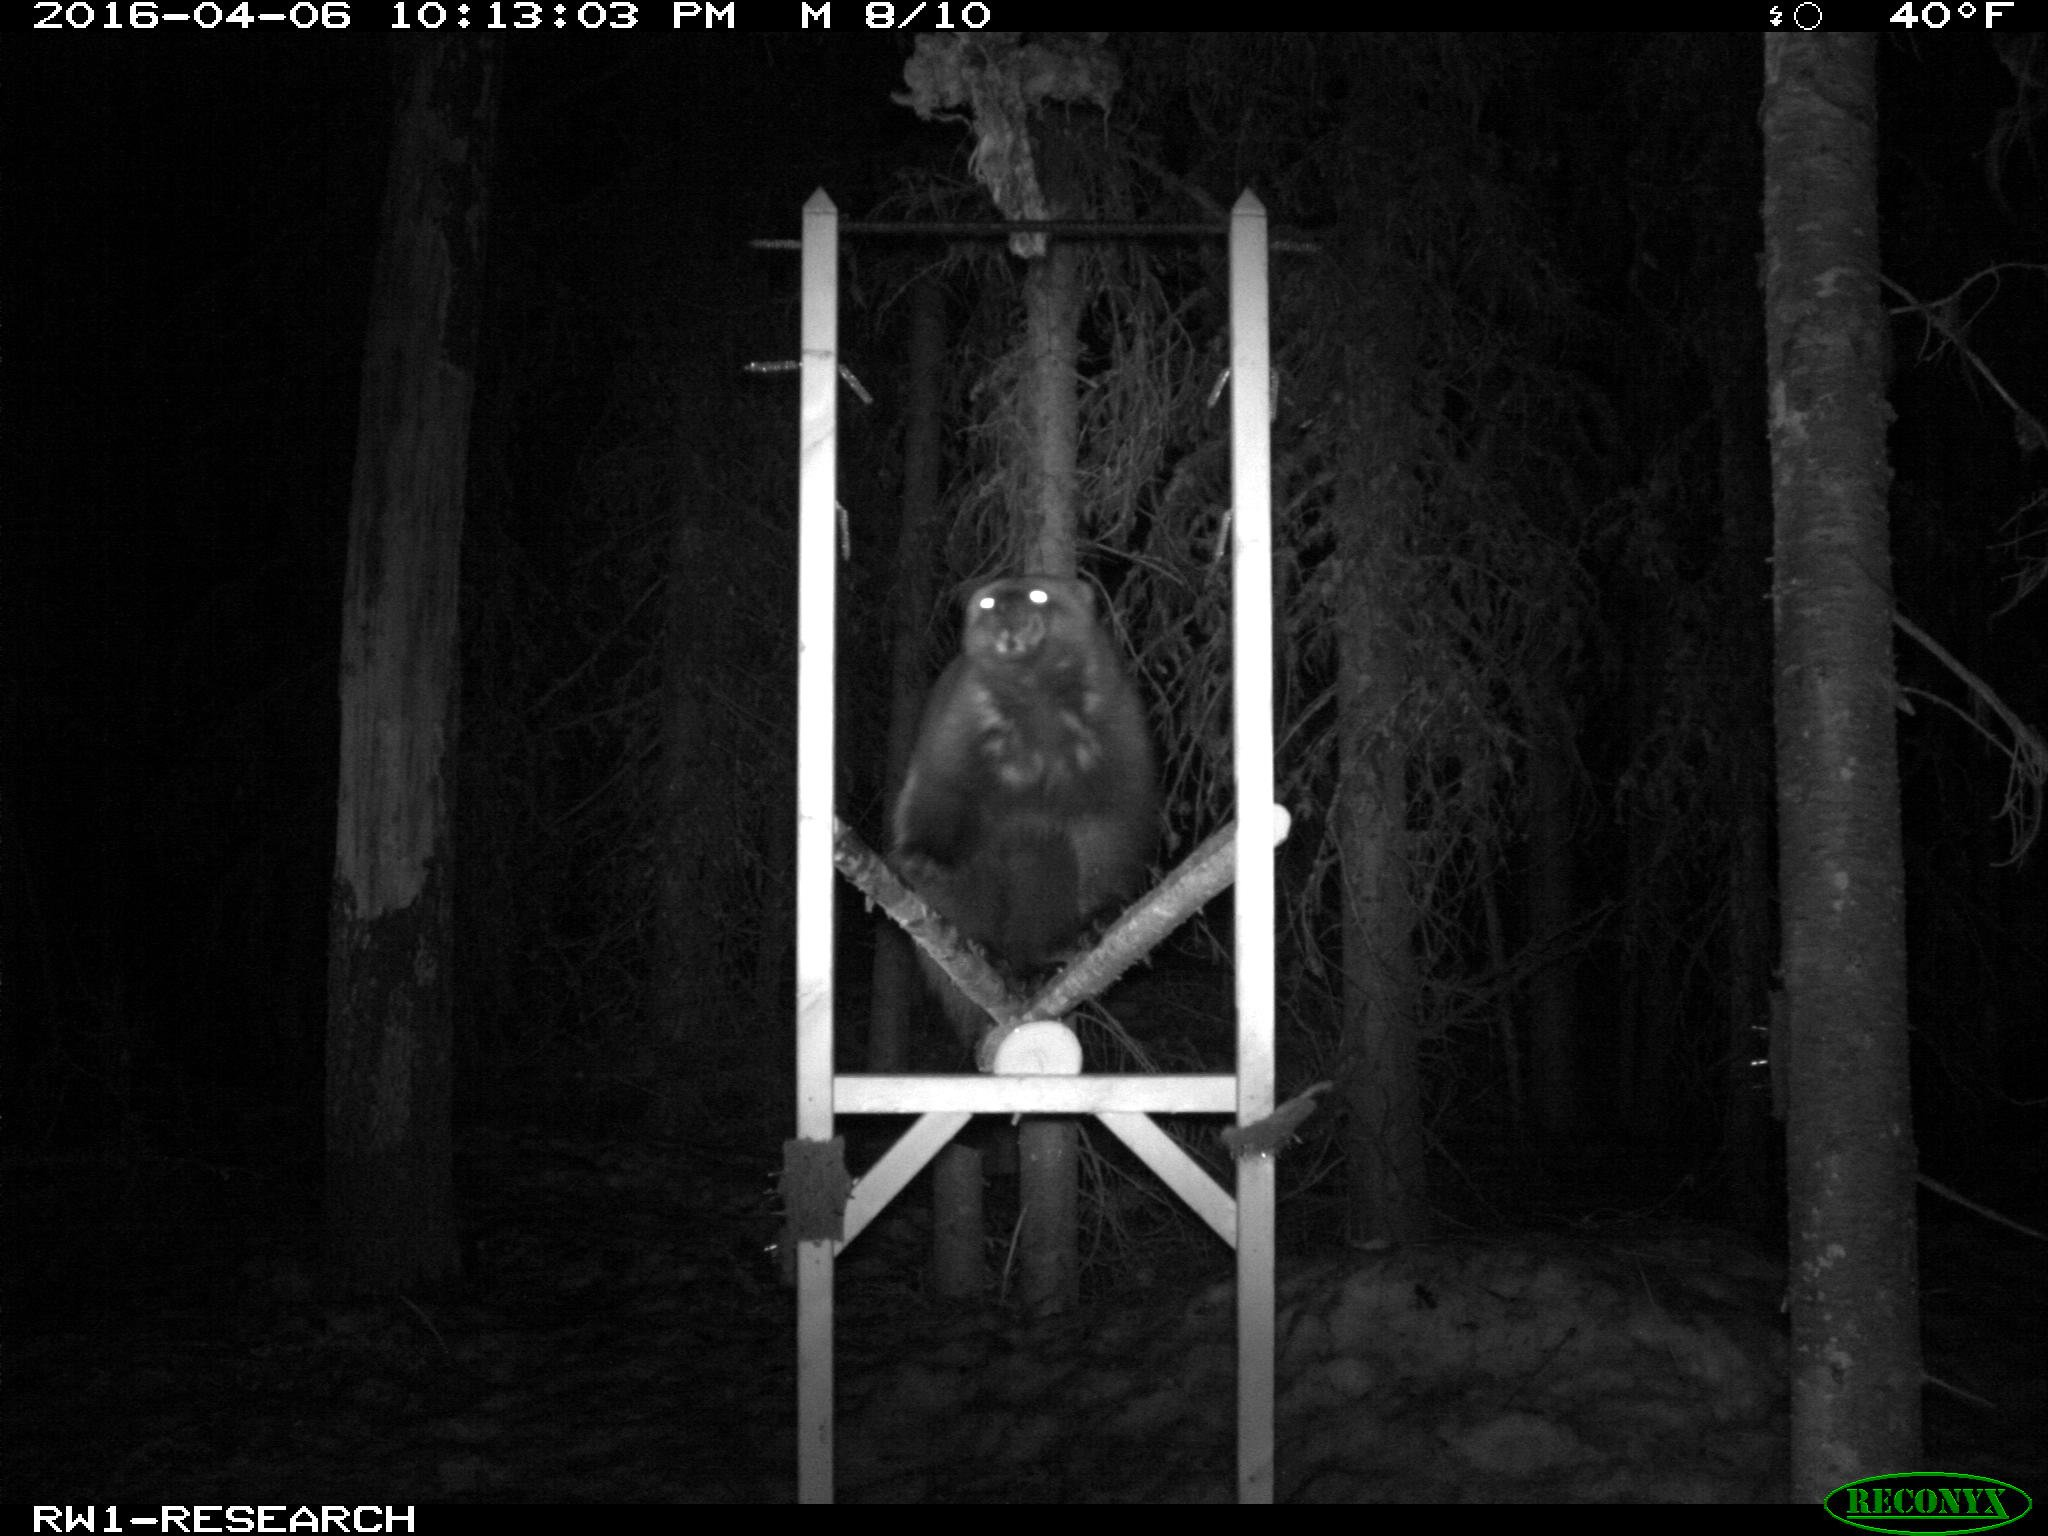

In [183]:
def load_and_decode_image(binary_image_data):
    """Decode binary image data and return an Image object."""
    image = Image.open(io.BytesIO(binary_image_data))
    return image

# Load one of the Parquet chunks
chunk_df = pd.read_parquet('data/parquet/train_0.parquet')

# Assume the encoded images are in the 'image' column
# Choose an image to open, for example, the first one
encoded_image = chunk_df['image'].iloc[0]

# Decode and open the image
image = load_and_decode_image(encoded_image)

# Now you can display or process the image
image

In [184]:
chunk_df['ymdh'].iloc[0], chunk_df['marks'].iloc[0], chunk_df['color'].iloc[0]

('201604062211', 'Robust', 0)

In [185]:
chunk_df.head()

,group,species,id,station,year,color,marks,ymdh,label,image
0,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,Robust,201604062211,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
1,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,Robust,201604062211,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
2,Focal_species,Gulo gulo,BDF10-M6,CC,2016,0,Robust,201604062211,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
3,Focal_species,Gulo gulo,BDF10-M6,HC,2016,0,Robust,201603081818,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
4,Focal_species,Gulo gulo,BDF10-M6,HC,2016,0,Robust,201603081818,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
